# IMPORT

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# LOAD DATA

load data from [backgroundmodelschallenge](https://backgroundmodelschallenge.eu/)

In [6]:
video = cv2.VideoCapture("./data/Video_008/Video_008.avi")

frames = []

while True:
    ret, frame = video.read()

    if not ret:
        break

    frames.append(frame)

video.release()

frames = np.array(frames)

frames, H, W, colors

In [7]:
frames.shape

(792, 240, 320, 3)

separating colors

In [9]:
blue = frames[:, :, :, 0]
green = frames[:, :, :, 1]
red = frames[:, :, :, 2]

example of separating

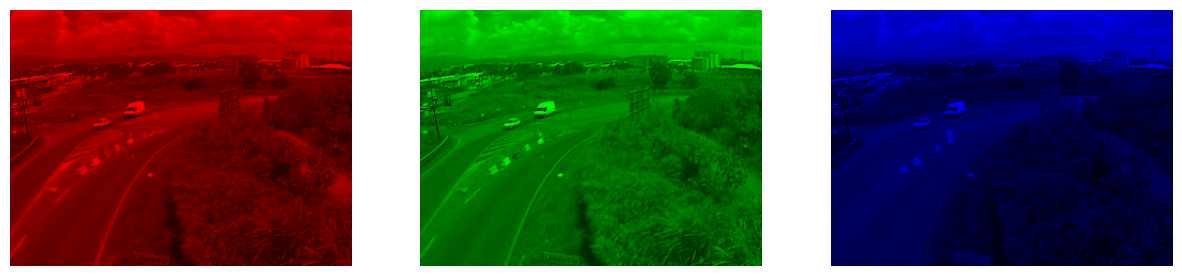

In [ ]:
h, w = frames.shape[1], frames.shape[2]
frame_idx = 0

pure_blue = np.zeros((h, w, 3), dtype=np.uint8)
pure_blue[:, :, 2] = blue[frame_idx]

pure_green = np.zeros((h, w, 3), dtype=np.uint8)
pure_green[:, :, 1] = green[frame_idx]

pure_red = np.zeros((h, w, 3), dtype=np.uint8)
pure_red[:, :, 0] = red[frame_idx]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].imshow(pure_red)
axs[0].axis('off')

axs[1].imshow(pure_green)
axs[1].axis('off')

axs[2].imshow(pure_blue)
axs[2].axis('off')

plt.show()


function for svd

In [18]:
def prepare_matrix(channel):
    T, H, W = channel.shape

    X = channel.reshape(T, H * W).T

    U, S, Vt = np.linalg.svd(X, full_matrices=False)

    return U, S, Vt, H, W

svd decomposition

In [19]:
U_B, S_B, Vt_B, H, W = prepare_matrix(blue)
U_G, S_G, Vt_G, _, _ = prepare_matrix(green)
U_R, S_R, Vt_R, _, _ = prepare_matrix(red)

reconstruction

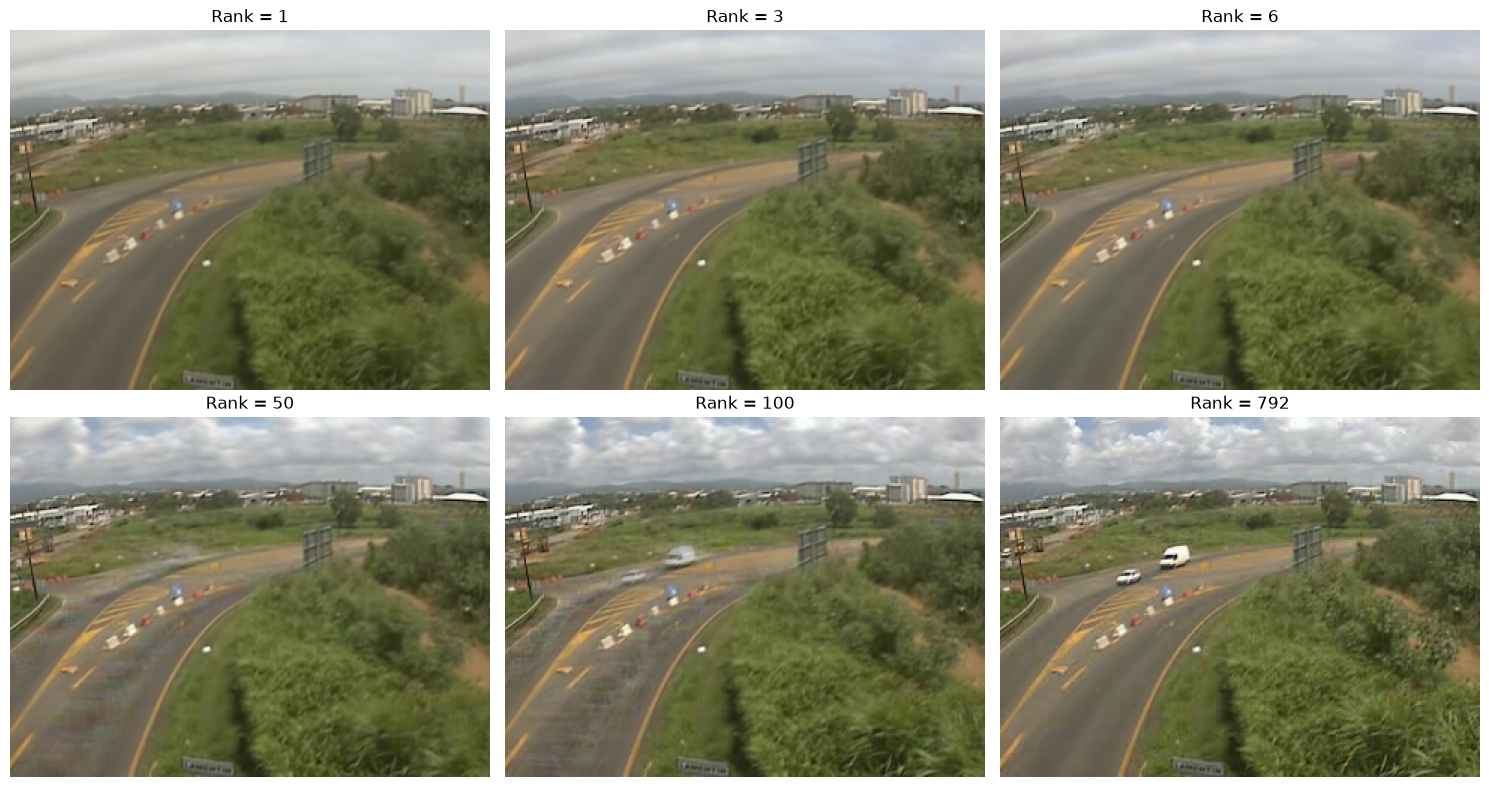

In [25]:
ranks = [1, 3, 6, 50, 100, len(S_B)]

frame_idx = 0

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, k in zip(axes.flat, ranks):

    B_k = (U_B[:, :k] * S_B[:k]) @ Vt_B[:k, :]
    G_k = (U_G[:, :k] * S_G[:k]) @ Vt_G[:k, :]
    R_k = (U_R[:, :k] * S_R[:k]) @ Vt_R[:k, :]

    B_first = B_k[:, frame_idx].reshape(H, W)
    G_first = G_k[:, frame_idx].reshape(H, W)
    R_first = R_k[:, frame_idx].reshape(H, W)

    background = np.stack(
        [B_first, G_first, R_first],
        axis=2
    )

    background = np.clip(
        background,
        0,
        255
    ).astype(np.uint8)

    ax.imshow(
        cv2.cvtColor(background, cv2.COLOR_BGR2RGB)
    )

    ax.set_title(f"Rank = {k}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Summary of the results:

- Rank 1 to 6: The algorithm successfully shows only the static background (the road and trees). All moving cars are completely gone.

- Rank 50 to 100: Finer details and changing elements begin to return. The moving cars reappear as blurry, faint "ghost" images.

- Rank 792: The frame is 100% reconstructed. The white van and the car are fully visible and sharp.Conclusion:Low SVD ranks capture the permanent, unchanging background. High SVD ranks capture the moving traffic and temporary details.